XGBoost Results - Default Threshold 0.50
Precision : 0.4657
Recall    : 0.6146
F1-Score  : 0.5299
ROC-AUC   : 0.7756

Confusion Matrix:
[[3732  935]
 [ 511  815]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4667
           1       0.47      0.61      0.53      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.71      0.68      5993
weighted avg       0.79      0.76      0.77      5993


XGBoost Results - Optimized Threshold
Best Threshold: 0.55
Precision     : 0.5075
Recall        : 0.5633
F1-Score      : 0.534
ROC-AUC       : 0.7756

Optimized Confusion Matrix:
[[3942  725]
 [ 579  747]]

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4667
           1       0.51      0.56      0.53      1326

    accuracy                           0.78      5993
   macro avg       0.69    

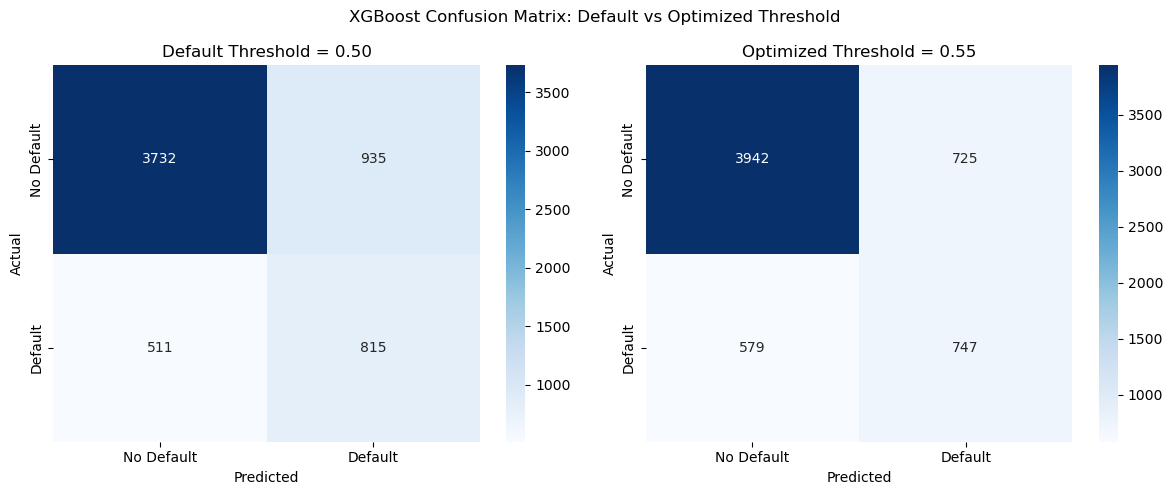

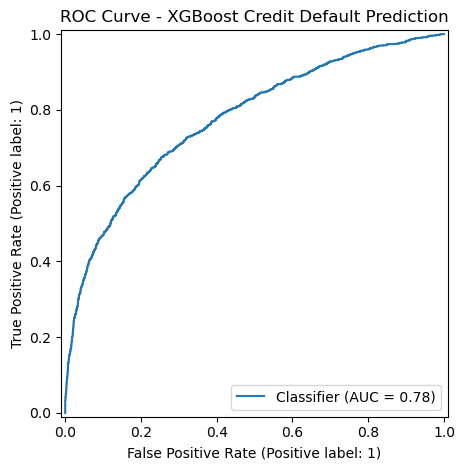


Top 10 Important Features:
       Feature  Importance
26   MAX_DELAY    0.351121
27  LATE_COUNT    0.143802
5        PAY_1    0.107697
23  TOTAL_BILL    0.025176
6        PAY_2    0.022030
24   TOTAL_PAY    0.020128
0    LIMIT_BAL    0.019314
11   BILL_AMT1    0.017947
18    PAY_AMT2    0.016462
25   PAY_RATIO    0.016219


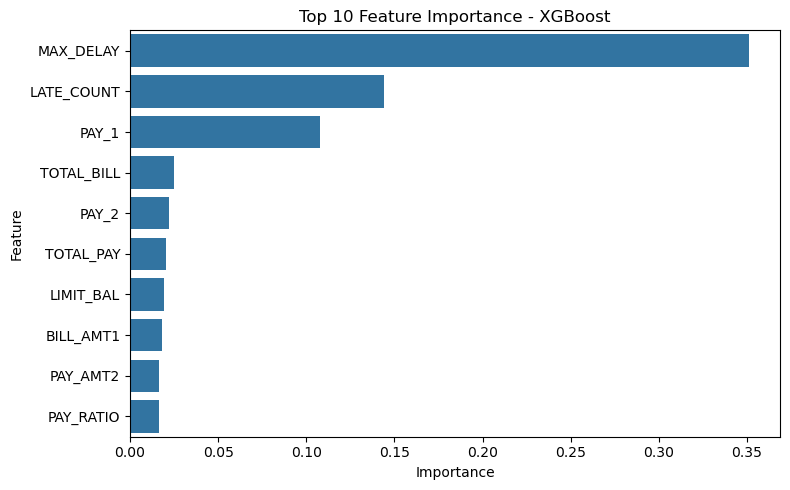

In [9]:
# CreditRiskIQ - XGBoost Model 


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier


# 1. Load dataset
df = pd.read_csv("/Users/natianaurdaneta/Documents/10th Semester UCF/STA4365/UCI_Credit_Card.csv.zip")


# 2. Clean dataset
df = df.rename(columns={
    "default.payment.next.month": "DEFAULT",
    "PAY_0": "PAY_1"
})

if "ID" in df.columns:
    df = df.drop(columns=["ID"])

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

df = df.drop_duplicates()


# 3. Feature engineering
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

pay_status_cols = [
    "PAY_1", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)
df["TOTAL_PAY"] = df[pay_amt_cols].sum(axis=1)
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1)
df["MAX_DELAY"] = df[pay_status_cols].max(axis=1)
df["LATE_COUNT"] = (df[pay_status_cols] > 0).sum(axis=1)


# 4. Define X and y
X = df.drop(columns=["DEFAULT"])
y = df["DEFAULT"]


# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 6. Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


# 7. Train XGBoost model
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)


# 8. Predictions using default threshold 0.50
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.50).astype(int)


# 9. Default threshold metrics
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)
roc_auc = roc_auc_score(y_test, y_prob)
cm_default = confusion_matrix(y_test, y_pred_default)

print("XGBoost Results - Default Threshold 0.50")
print("========================================")
print("Precision :", round(precision_default, 4))
print("Recall    :", round(recall_default, 4))
print("F1-Score  :", round(f1_default, 4))
print("ROC-AUC   :", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(cm_default)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))


# 10. Threshold optimization using F1-score
thresholds = np.arange(0.10, 0.90, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    current_f1 = f1_score(y_test, y_pred_threshold)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold


# 11. Optimized threshold metrics
y_pred_opt = (y_prob >= best_threshold).astype(int)

precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
cm_opt = confusion_matrix(y_test, y_pred_opt)

print("\nXGBoost Results - Optimized Threshold")
print("=====================================")
print("Best Threshold:", round(best_threshold, 2))
print("Precision     :", round(precision_opt, 4))
print("Recall        :", round(recall_opt, 4))
print("F1-Score      :", round(f1_opt, 4))
print("ROC-AUC       :", round(roc_auc, 4))

print("\nOptimized Confusion Matrix:")
print(cm_opt)

print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_opt))


# 12. Plot default vs optimized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)
axes[0].set_title("Default Threshold = 0.50")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)
axes[1].set_title(f"Optimized Threshold = {round(best_threshold, 2)}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("XGBoost Confusion Matrix: Default vs Optimized Threshold")
plt.tight_layout()
plt.show()


# 13. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - XGBoost Credit Default Prediction")
plt.tight_layout()
plt.show()


# 14. Top 10 Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top10 = feature_importance.head(10)

print("\nTop 10 Important Features:")
print(top10)


plt.figure(figsize=(8, 5))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

